# Module 5: Spatial Trends — Calculating and Mapping Long-Term Warming

In climate science, determining whether a region is warming or cooling requires computing the **linear trend** over time.

### 1. The Mathematical Model
For every single grid point $(\text{lat}, \text{lon})$, we fit a simple ordinary least squares linear regression model:

$$T(t) = m \cdot t + c$$

Where:
* $t$ is time.
* $c$ is the intercept.
* $m = \frac{dT}{dt}$ is the **slope (trend)** representing the rate of temperature change per unit time.

### 2. Time Aggregation (Annual Means)
Calculating trends directly on raw monthly data can be noisy due to strong seasonal cycles. A standard practice is to first compute the **annual mean** time series for each calendar year, then calculate the linear trend across the years:

$$\text{Decadal Trend} = m \left(\frac{^\circ\text{C}}{\text{year}}\right) \times 10 \left(\frac{\text{years}}{\text{decade}}\right) \longrightarrow \left[^\circ\text{C}/\text{decade}\right]$$

In [13]:
import xarray as xr

# 1. Open the Long-Term Monthly Mean (LTM) 4D atmospheric temperature dataset
ds_ltm = xr.open_dataset('data/air.mon.ltm.nc')
# 2. Open the Continuous Monthly Mean 3D surface (2m) temperature dataset
ds_2m = xr.open_dataset('data/air.2m.mon.mean.nc')

ds_2m

/tmp/ipykernel_1220682/1206937955.py:4: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  ds_ltm = xr.open_dataset('data/air.mon.ltm.nc')
/tmp/ipykernel_1220682/1206937955.py:4: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  ds_ltm = xr.open_dataset('data/air.mon.ltm.nc')


<xarray.Dataset> Size: 38MB
Dimensions:    (time: 529, nbnds: 2, level: 1, lat: 94, lon: 192)
Coordinates:
  * time       (time) datetime64[ns] 4kB 1979-01-01 1979-02-01 ... 2023-01-01
  * level      (level) float32 4B 2.0
  * lat        (lat) float32 376B 88.54 86.65 84.75 ... -84.75 -86.65 -88.54
  * lon        (lon) float32 768B 0.0 1.875 3.75 5.625 ... 354.4 356.2 358.1
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) datetime64[ns] 8kB ...
    air        (time, level, lat, lon) float32 38MB ...
Attributes:
    Conventions:    CF-1.0
    title:          Monthly NCEP/DOE Reanalysis 2
    comments:       Data is from \nNCEP/DOE AMIP-II Reanalysis (Reanalysis-2)...
    platform:       Model
    source:         NCEP/DOE AMIP-II Reanalysis (Reanalysis-2) Model
    institution:    National Centers for Environmental Prediction
    dataset_title:  NCEP-DOE AMIP-II Reanalysis
    References:     https://www.psl.noaa.gov/data/gridded/data.ncep.reanalysi...
    source_url:     http://www.cpc.ncep.noaa.gov/products/wesley/reanalysis2/
    history:        created 2002/03 by Hoop (netCDF2.3)\nConverted to chunked...

In [3]:
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
import cartopy.io.shapereader as shpreader
import matplotlib.pyplot as plt
import numpy as np
import os
import xarray as xr

# 1. Clean data: squeeze singleton dimensions and convert to Celsius
t2m = (ds_2m['air'] - 273.15).squeeze()
t2m.attrs['units'] = '°C'

# Ensure latitudes are sorted ascending
if t2m.lat[0] > t2m.lat[-1]:
  t2m = t2m.sortby('lat')

# 2. Resample from monthly to Annual Mean (1YS = Year Start frequency)
# This reduces 529 months to 44 complete annual averages (1979 to 2022)
t2m_annual = (
    t2m.sel(time=slice('1979-01-01', '2022-12-31'))
    .resample(time='1YS')
    .mean(dim='time')
)

print('Original Monthly Dimensions:', dict(t2m.sizes))
print('Annual Mean Dimensions:     ', dict(t2m_annual.sizes))

Original Monthly Dimensions: {'time': 529, 'lat': 94, 'lon': 192}
Annual Mean Dimensions:      {'time': 44, 'lat': 94, 'lon': 192}


### 3. Calculating the Slope Across Every Grid Cell (`xr.DataArray.polyfit`)

Doing a linear fit using nested `for` loops across $94 \times 192 = 18,048$ grid points in Python would take hundreds of lines and run slowly.

`xarray` provides **`.polyfit(dim='time', deg=1)`**, which vectorizes the least-squares regression across all spatial dimensions simultaneously.

In [4]:
# Fit a 1st-degree polynomial (linear fit: y = mx + c) along the time axis
fit_results = t2m_annual.polyfit(dim='time', deg=1)

# Inspect what polyfit returns
print(fit_results)

<xarray.Dataset> Size: 290kB
Dimensions:               (degree: 2, lat: 94, lon: 192)
Coordinates:
  * degree                (degree) int64 16B 1 0
  * lat                   (lat) float32 376B -88.54 -86.65 ... 86.65 88.54
  * lon                   (lon) float32 768B 0.0 1.875 3.75 ... 356.2 358.1
Data variables:
    polyfit_coefficients  (degree, lat, lon) float64 289kB 1.092e-18 ... -18.89


### 4. Unit Conversion: Converting from Nanoseconds to Decades

`xarray` calculates time coordinates internally using nanoseconds ($1\text{ s} = 10^9\text{ ns}$). 

The raw slope (`polyfit_coefficients.sel(degree=1)`) has units of:
$$\left[\frac{^\circ\text{C}}{\text{nanosecond}}\right]$$

To convert this slope to **$^\circ\text{C} / \text{decade}$**, we multiply by the number of nanoseconds in 10 years:

$$\text{Scale Factor} = 10^9 \left(\frac{\text{ns}}{\text{s}}\right) \times 86400 \left(\frac{\text{s}}{\text{day}}\right) \times 365.25 \left(\frac{\text{days}}{\text{year}}\right) \times 10 \left(\frac{\text{years}}{\text{decade}}\right)$$

In [5]:
# Raw slope in degC / nanosecond
slope_raw = fit_results['polyfit_coefficients'].sel(degree=1)

# Nanoseconds in 10 Julian years (1 decade)
ns_per_decade = 1e9 * 86400 * 365.25 * 10

# Scaled warming trend per decade
trend_per_decade = slope_raw * ns_per_decade
trend_per_decade.attrs['units'] = '°C/decade'

print(
    f'Global Maximum Warming Rate: {float(trend_per_decade.max()):+.3f}'
    ' °C/decade'
)
print(
    f'Global Minimum Warming Rate: {float(trend_per_decade.min()):+.3f}'
    ' °C/decade'
)
print(
    f'Global Mean Warming Rate:    {float(trend_per_decade.mean()):+.3f}'
    ' °C/decade'
)

Global Maximum Warming Rate: +2.179 °C/decade
Global Minimum Warming Rate: -1.626 °C/decade
Global Mean Warming Rate:    +0.304 °C/decade


### 5. Plotting Global Warming Trends (1979–2022)

Let us plot the global spatial pattern of the decadal warming rate. 

Notice the prominent phenomenon of **Arctic Amplification**: high northern latitudes warm at more than double the global average rate.

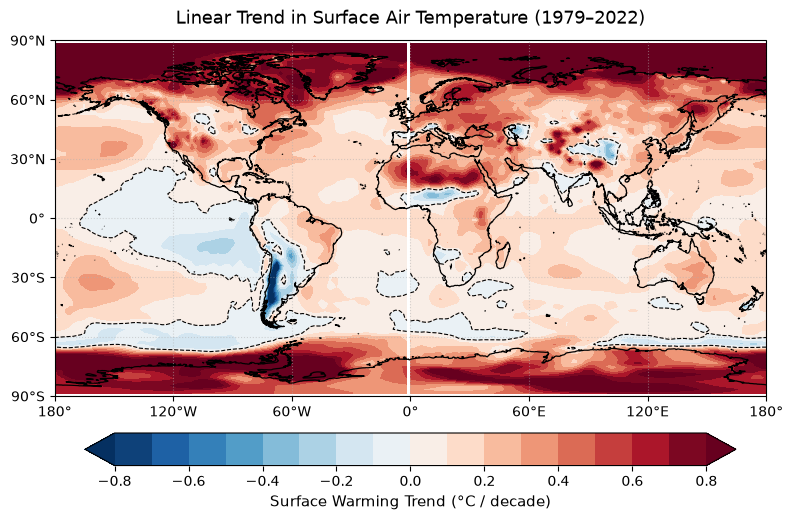

In [6]:
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Diverging color palette centered at 0: cool (blue) vs warm (red)
trend_levels = np.arange(-0.8, 0.9, 0.1)

cf = ax.contourf(
    trend_per_decade.lon.values,
    trend_per_decade.lat.values,
    trend_per_decade.values,
    levels=trend_levels,
    cmap='RdBu_r',
    transform=ccrs.PlateCarree(),
    extend='both',
)

# Zero trend contour line
ax.contour(
    trend_per_decade.lon.values,
    trend_per_decade.lat.values,
    trend_per_decade.values,
    levels=[0.0],
    colors='black',
    linewidths=0.8,
    linestyles='--',
    transform=ccrs.PlateCarree(),
)

# Physical coastlines using local shapefile
shp_path = os.path.expanduser(
    '~/.local/share/cartopy/shapefiles/natural_earth/physical/ne_50m_coastline.shp'
)
if os.path.exists(shp_path):
  coastline_geometries = list(shpreader.Reader(shp_path).geometries())
  ax.add_geometries(
      coastline_geometries,
      crs=ccrs.PlateCarree(),
      edgecolor='black',
      facecolor='none',
      linewidth=0.9,
  )

# Coordinate tick marks
ax.set_xticks(np.arange(-180, 181, 60), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(-90, 91, 30), crs=ccrs.PlateCarree())
ax.xaxis.set_major_formatter(LongitudeFormatter())
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.grid(True, linestyle=':', alpha=0.5)

# Colorbar
cbar = plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.08, shrink=0.7)
cbar.set_label('Surface Warming Trend (°C / decade)', fontsize=11)

plt.title(
    'Linear Trend in Surface Air Temperature (1979–2022)', fontsize=13, pad=12
)
plt.show()

### 6. Regional Warming Trends: South Asia / Indian Subcontinent

Now let us zoom into the South Asian domain ($60^\circ\text{E}-100^\circ\text{E}, 5^\circ\text{N}-38^\circ\text{N}$) to examine regional warming rates across the subcontinent, the Himalayas, and the northern Indian Ocean.

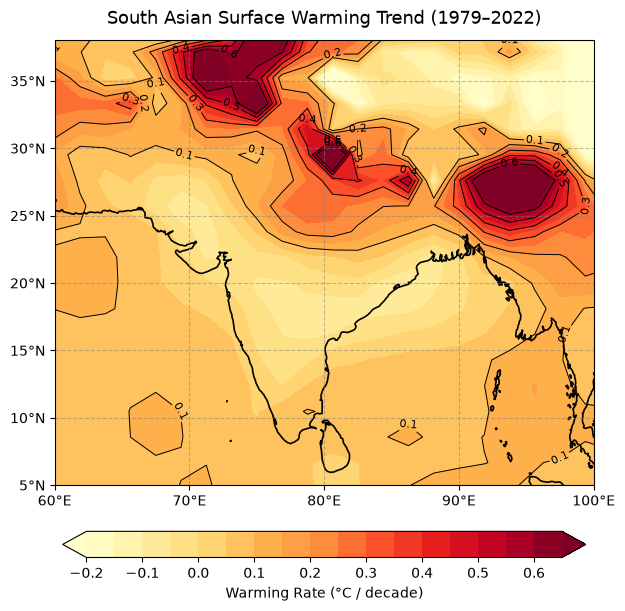

In [7]:
# Slice regional domain
trend_sa = trend_per_decade.sel(lat=slice(0, 42), lon=slice(55, 105))

fig = plt.figure(figsize=(9, 7.5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([60, 100, 5, 38], crs=ccrs.PlateCarree())

# Regional trend levels with finer color steps
regional_trend_levels = np.arange(-0.2, 0.7, 0.05)

cf = ax.contourf(
    trend_sa.lon.values,
    trend_sa.lat.values,
    trend_sa.values,
    levels=regional_trend_levels,
    cmap='YlOrRd',
    transform=ccrs.PlateCarree(),
    extend='both',
)

# Overlay trend contours with labels
cs = ax.contour(
    trend_sa.lon.values,
    trend_sa.lat.values,
    trend_sa.values,
    levels=np.arange(0.1, 0.7, 0.1),
    colors='black',
    linewidths=0.7,
    transform=ccrs.PlateCarree(),
)
ax.clabel(cs, inline=True, fontsize=8, fmt='%.1f')

# Add coastlines
if os.path.exists(shp_path):
  ax.add_geometries(
      coastline_geometries,
      crs=ccrs.PlateCarree(),
      edgecolor='black',
      facecolor='none',
      linewidth=1.2,
  )

# Coordinate tick marks & formatters
ax.set_xticks(np.arange(60, 101, 10), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(5, 39, 5), crs=ccrs.PlateCarree())
ax.xaxis.set_major_formatter(LongitudeFormatter())
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.grid(True, linestyle='--', color='gray', alpha=0.5)

# Colorbar
cbar = plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.08, shrink=0.75)
cbar.set_label('Warming Rate (°C / decade)', fontsize=10)

plt.title(
    'South Asian Surface Warming Trend (1979–2022)', fontsize=13, pad=12
)
plt.show()

# Module 6: Spatial Regridding & Model-Observation Comparison

In climate research, we routinely compare datasets from different sources:
* **Climate Model Simulations (e.g., CMIP6):** Often simulated on curvilinear ocean grids or spectral Gaussian atmospheric grids (e.g., T62, ~$1.875^\circ$).
* **Reanalysis / Observations (e.g., NCEP, ERA5, IMD):** Often archived on regular latitude-longitude grids (e.g., $0.25^\circ$, $1.0^\circ$, or $2.5^\circ$).

### The Problem: We Cannot Subtract Arrays of Different Shapes!
If we try to subtract two datasets directly:
$$\text{Model Bias} = T_{\text{model}} - T_{\text{obs}}$$

Python will throw an error or produce empty arrays if the coordinate points do not match exactly.

| Dataset | Grid Type | Dimensions (`lat` $\times$ `lon`) | Total Points |
| :--- | :--- | :--- | :--- |
| `air.2m.mon.mean.nc` | **T62 Gaussian** (irregular lat spacing) | $94 \times 192$ | 18,048 |
| `air.mon.ltm.nc` | **Regular Grid** (constant $\Delta = 2.5^\circ$) | $73 \times 144$ | 10,512 |

To compare them, we must **regrid (interpolate)** one field onto the target coordinate system of the other.

### 1. Inspecting Grid Incompatibilities

Let's examine why these two grids cannot be combined directly by checking their coordinate spacings ($\Delta\text{lat}$ and $\Delta\text{lon}$).

In [8]:
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

# Load both datasets
ds_2m = xr.open_dataset('data/air.2m.mon.mean.nc')
ds_ltm = xr.open_dataset('data/air.mon.ltm.nc', use_cftime=True)

# 1. Target Grid: LTM regular grid (2.5° x 2.5°)
target_lat = ds_ltm.lat.values
target_lon = ds_ltm.lon.values

# 2. Source Grid: 2m Continuous Gaussian grid (~1.875° x 1.9°)
source_lat = ds_2m.lat.values
source_lon = ds_2m.lon.values

print(f"Target Grid Shape (LTM):     {len(target_lat)} lats x {len(target_lon)} lons")
print(f"Target Lat Spacing (Δlat):   {np.diff(target_lat)[:3]} (Uniform 2.5° steps)")

print(f"\nSource Grid Shape (2m Mean): {len(source_lat)} lats x {len(source_lon)} lons")
print(f"Source Lat Spacing (Δlat):   {np.round(np.diff(source_lat)[:4], 4)} (Non-uniform Gaussian steps)")

Target Grid Shape (LTM):     73 lats x 144 lons
Target Lat Spacing (Δlat):   [-2.5 -2.5 -2.5] (Uniform 2.5° steps)

Source Grid Shape (2m Mean): 94 lats x 192 lons
Source Lat Spacing (Δlat):   [-1.8889 -1.8999 -1.9024 -1.9035] (Non-uniform Gaussian steps)


/tmp/ipykernel_1220682/4282161020.py:9: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds_ltm = xr.open_dataset('data/air.mon.ltm.nc', use_cftime=True)


### 2. Visualizing Grid Cell Alignment

Let's plot the grid centers of both datasets over India. Notice how the points do not align—they fall in different physical geographic positions.

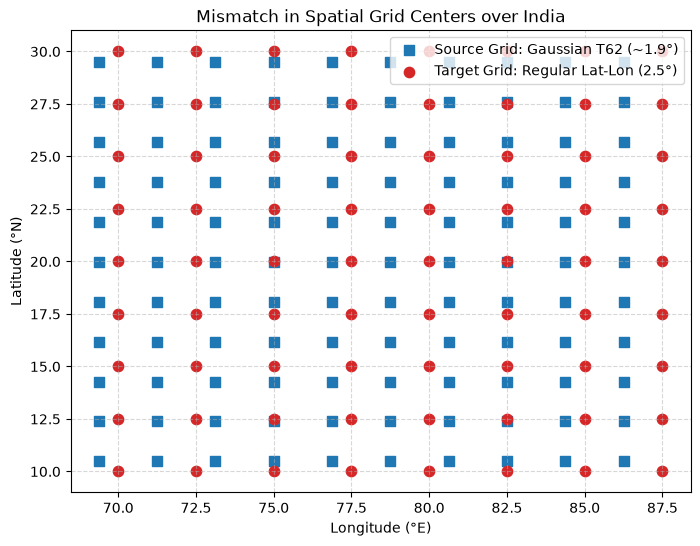

In [9]:
# Create 2D meshgrids for both coordinate systems
target_lons_2d, target_lats_2d = np.meshgrid(target_lon, target_lat)
source_lons_2d, source_lats_2d = np.meshgrid(source_lon, source_lat)

# Filter points within South Asia
mask_target = (target_lons_2d >= 68) & (target_lons_2d <= 88) & (target_lats_2d >= 10) & (target_lats_2d <= 30)
mask_source = (source_lons_2d >= 68) & (source_lons_2d <= 88) & (source_lats_2d >= 10) & (source_lats_2d <= 30)

plt.figure(figsize=(8, 6))
plt.scatter(source_lons_2d[mask_source], source_lats_2d[mask_source], color='tab:blue', marker='s', s=45, label='Source Grid: Gaussian T62 (~1.9°)')
plt.scatter(target_lons_2d[mask_target], target_lats_2d[mask_target], color='tab:red', marker='o', s=55, label='Target Grid: Regular Lat-Lon (2.5°)')

plt.title('Mismatch in Spatial Grid Centers over India', fontsize=12)
plt.xlabel('Longitude (°E)')
plt.ylabel('Latitude (°N)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 3. Bilinear Interpolation using `xarray.interp_like()`

**Bilinear interpolation** estimates the value at each new target grid point by taking a distance-weighted average of the 4 surrounding source grid points.

In `xarray`, this requires a single method call: **`source_da.interp_like(target_da, method='linear')`**. In `xarray` , _bilinear interpolation_ is segregated under _linear_ function, hence, calling _method=linear_

In [15]:
# Prepare source variable: July mean temperature from the continuous dataset
t2m_source = (
    (ds_2m['air'].groupby('time.month').mean(dim='time') - 273.15)
    .sel(month=7)
    .squeeze()
)

# Target grid variable: July 1000 hPa temperature from the LTM dataset
t_target = (ds_ltm['air'].sel(level=1000).isel(time=6) - 273.15).squeeze()

# Ensure both have ascending latitudes
if t2m_source.lat[0] > t2m_source.lat[-1]:
  t2m_source = t2m_source.sortby('lat')
if t_target.lat[0] > t_target.lat[-1]:
  t_target = t_target.sortby('lat')

# --- Perform Regridding using method='linear' ---
t2m_regridded = t2m_source.interp_like(t_target, method='linear')

print("=== Regridding Results ===")
print("Original Source Shape: ", t2m_source.shape, "(lat x lon)")
print("Target Reference Shape:", t_target.shape, "(lat x lon)")
print(
    "Regridded Output Shape:",
    t2m_regridded.shape,
    "(Matches Target Exactly!)",
)

=== Regridding Results ===
Original Source Shape:  (94, 192) (lat x lon)
Target Reference Shape: (73, 144) (lat x lon)
Regridded Output Shape: (73, 144) (Matches Target Exactly!)


### 4. Computing the Difference / Bias Field

Now that both arrays share identical dimensions, coordinates, and shapes ($73 \times 144$), we can perform array arithmetic:

$$\Delta T = T_{\text{2m, regridded}} - T_{\text{1000hPa, LTM}}$$

In [16]:
# Direct array subtraction (Valid now that coordinates match)
diff_field = t2m_regridded - t_target
diff_field.attrs['units'] = '°C'

print("Difference array shape:", diff_field.shape)
print(f"Mean Difference: {float(diff_field.mean()):+.2f} °C")
print(f"Max Difference:  {float(diff_field.max()):+.2f} °C")
print(f"Min Difference:  {float(diff_field.min()):+.2f} °C")

Difference array shape: (73, 144)
Mean Difference: -2.69 °C
Max Difference:  +3.40 °C
Min Difference:  -36.33 °C


### 5. Visualizing the Before, After, and Difference Fields

Let's plot all three fields side-by-side to inspect the interpolation and differences over South Asia.

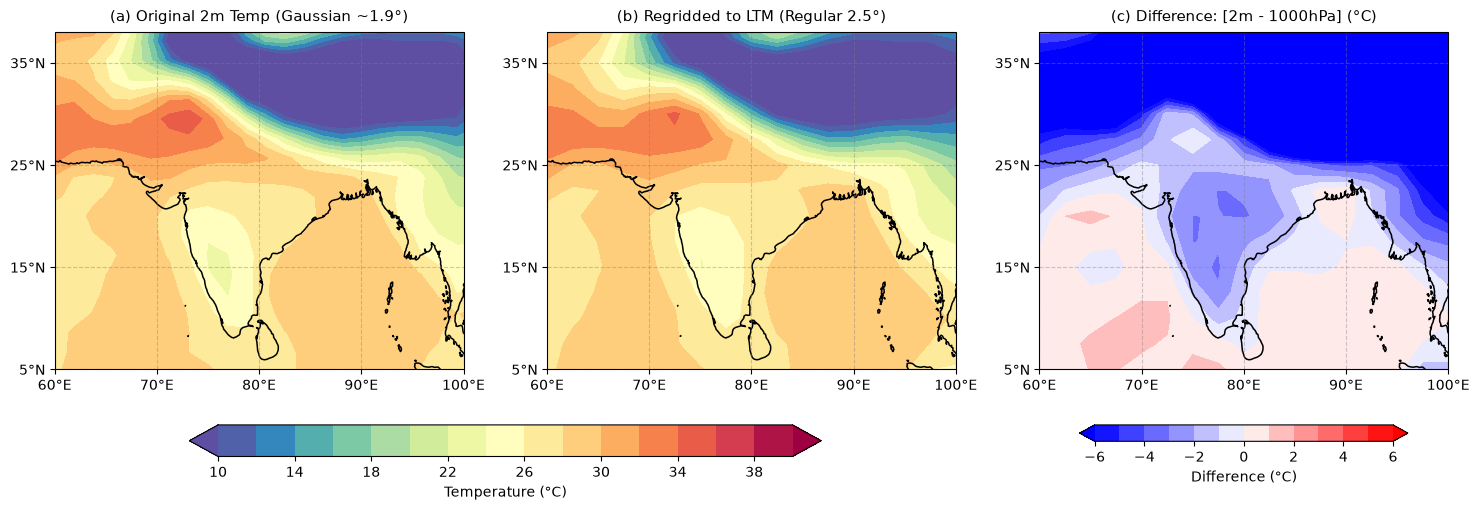

In [18]:
import os
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
import cartopy.io.shapereader as shpreader
import matplotlib.pyplot as plt
import numpy as np

# 1. Load physical coastlines directly from local cache
shp_path = os.path.expanduser(
    '~/.local/share/cartopy/shapefiles/natural_earth/physical/ne_50m_coastline.shp'
)
coastline_geometries = list(shpreader.Reader(shp_path).geometries())

# 2. Slice domains for plotting
t_src_sub = t2m_source.sel(lat=slice(0, 42), lon=slice(55, 105))
t_reg_sub = t2m_regridded.sel(lat=slice(0, 42), lon=slice(55, 105))
t_dif_sub = diff_field.sel(lat=slice(0, 42), lon=slice(55, 105))

fig, (ax1, ax2, ax3) = plt.subplots(
    1, 3, figsize=(18, 6), subplot_kw={'projection': ccrs.PlateCarree()}
)

ax1.set_extent([60, 100, 5, 38], crs=ccrs.PlateCarree())
cf1 = ax1.contourf(
    t_src_sub.lon.values,
    t_src_sub.lat.values,
    t_src_sub.values,
    levels=np.arange(10, 42, 2),
    cmap='Spectral_r',
    transform=ccrs.PlateCarree(),
    extend='both',
)
ax1.add_geometries(
    coastline_geometries,
    crs=ccrs.PlateCarree(),
    edgecolor='black',
    facecolor='none',
    linewidth=1.1,
)
ax1.set_title('(a) Original 2m Temp (Gaussian ~1.9°)', fontsize=11, pad=8)


ax2.set_extent([60, 100, 5, 38], crs=ccrs.PlateCarree())
cf2 = ax2.contourf(
    t_reg_sub.lon.values,
    t_reg_sub.lat.values,
    t_reg_sub.values,
    levels=np.arange(10, 42, 2),
    cmap='Spectral_r',
    transform=ccrs.PlateCarree(),
    extend='both',
)
ax2.add_geometries(
    coastline_geometries,
    crs=ccrs.PlateCarree(),
    edgecolor='black',
    facecolor='none',
    linewidth=1.1,
)
ax2.set_title('(b) Regridded to LTM (Regular 2.5°)', fontsize=11, pad=8)


ax3.set_extent([60, 100, 5, 38], crs=ccrs.PlateCarree())
diff_levels = np.arange(-6, 7, 1)
cf3 = ax3.contourf(
    t_dif_sub.lon.values,
    t_dif_sub.lat.values,
    t_dif_sub.values,
    levels=diff_levels,
    cmap='bwr',
    transform=ccrs.PlateCarree(),
    extend='both',
)
ax3.add_geometries(
    coastline_geometries,
    crs=ccrs.PlateCarree(),
    edgecolor='black',
    facecolor='none',
    linewidth=1.1,
)
ax3.set_title('(c) Difference: [2m - 1000hPa] (°C)', fontsize=11, pad=8)


for ax in [ax1, ax2, ax3]:
  ax.set_xticks(np.arange(60, 101, 10), crs=ccrs.PlateCarree())
  ax.set_yticks(np.arange(5, 39, 10), crs=ccrs.PlateCarree())
  ax.xaxis.set_major_formatter(LongitudeFormatter())
  ax.yaxis.set_major_formatter(LatitudeFormatter())
  ax.grid(True, linestyle='--', color='gray', alpha=0.4)


cbar_temp = fig.colorbar(
    cf2, ax=[ax1, ax2], orientation='horizontal', pad=0.12, shrink=0.7
)
cbar_temp.set_label('Temperature (°C)', fontsize=10)

cbar_diff = fig.colorbar(
    cf3, ax=ax3, orientation='horizontal', pad=0.12, shrink=0.8
)
cbar_diff.set_label('Difference (°C)', fontsize=10)

plt.show()